In [ ]:
# !!! bNote to self !!!
# I don't think this is working as intended for me
# Especially there is this weird behaviour where the loss increases with a small learning rate

from odyssey.lightning.data.cpc_module import CPCDataModule
from odyssey.lightning.models.cpc import CPCModel

import torch
import torch.nn as nn
import torch.nn.functional as F
import lightning

import hydra
from hydra.core.hydra_config import HydraConfig
from omegaconf import OmegaConf

import os
import h5py

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
data_path = "/workspace/data/nld_nao_test.h5"
device = "cuda" if torch.cuda.is_available() else "cpu"

with hydra.initialize(version_base=None, config_path="../../config"):
    config = hydra.compose(
        config_name="train_cpc",
        overrides=[
            "model=cpc",
            "trainer=gpu",
            "paths=default",
            "logger=wandb",
            "logger.offline=True"
        ],
        return_hydra_config=True
    )
    HydraConfig.instance().set_config(config)

    lightning_model: CPCModel = hydra.utils.instantiate(config.model)
    trainer: lightning.Trainer = hydra.utils.instantiate(config.trainer)
    data_module: CPCDataModule = hydra.utils.instantiate(config.data)

/usr/local/lib/python3.10/dist-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.10/dist-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extr

You are using a CUDA device ('NVIDIA GeForce RTX 3070 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Data directory /workspace//data/nld_nao already contains files. Skipping download.
Database file /workspace//data/ttyrecs.db already exists. Skipping database creation.
Train file /workspace//data/nld_nao_train.h5 and test file /workspace//data/nld_nao_test.h5 already exist. Skipping HDF5 creation.


Finding best initial lr: 100%|██████████| 100/100 [01:36<00:00,  1.03it/s]
Learning rate set to 2.6302679918953824e-05
Restoring states from the checkpoint path at /workspace/notebooks/cpc/.lr_find_2de373fe-9eb5-4bbb-be18-c5b345079636.ckpt
Restored all states from the checkpoint at /workspace/notebooks/cpc/.lr_find_2de373fe-9eb5-4bbb-be18-c5b345079636.ckpt
/tmp/ipykernel_12850/2980534134.py:16: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


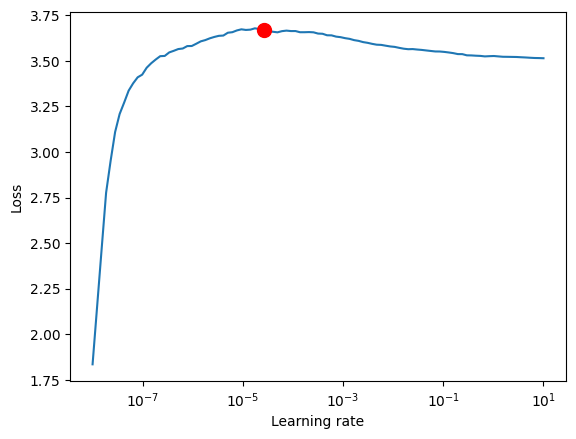

In [3]:
tuner = lightning.pytorch.tuner.Tuner(trainer)
data_module.prepare_data()
data_module.setup(stage="fit")
train_dataloader = data_module.train_dataloader()
val_dataloader = data_module.val_dataloader()

res = tuner.lr_find(
    lightning_model,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    max_lr=10.0,
    min_lr=1e-8,
)

fig = res.plot(suggest=True)
fig.show()

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Data directory /workspace//data/nld_nao already contains files. Skipping download.
Database file /workspace//data/ttyrecs.db already exists. Skipping database creation.
Train file /workspace//data/nld_nao_train.h5 and test file /workspace//data/nld_nao_test.h5 already exist. Skipping HDF5 creation.


Finding best initial lr: 100%|██████████| 100/100 [01:41<00:00,  1.01s/it]
Learning rate set to 4.6000000054
Restoring states from the checkpoint path at /workspace/notebooks/cpc/.lr_find_b076514a-cbff-454f-8c13-90a63ffbc7c6.ckpt
Restored all states from the checkpoint at /workspace/notebooks/cpc/.lr_find_b076514a-cbff-454f-8c13-90a63ffbc7c6.ckpt
/tmp/ipykernel_12850/2712577249.py:17: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


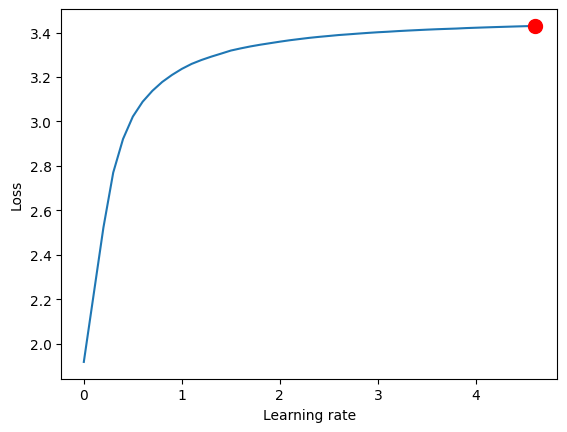

In [6]:
tuner = lightning.pytorch.tuner.Tuner(trainer)
data_module.prepare_data()
data_module.setup(stage="fit")
train_dataloader = data_module.train_dataloader()
val_dataloader = data_module.val_dataloader()

res = tuner.lr_find(
    lightning_model,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    max_lr=10.0,
    min_lr=1e-8,
    mode="linear"
)

fig = res.plot(suggest=True)
fig.show()